In [113]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances

# K-means

In [114]:
train = pd.read_csv('data/K_means_train.csv')
test = pd.read_csv('data/K_means_test.csv')
val = pd.read_csv('data/K_means_valid_9.csv')

In [115]:
# step 1: pick k=3 centroids randomly
centroids = train.sample(n=3)
print('Initial centroids:')
print(centroids)
old_centroids = pd.DataFrame()   # will be the previous version of a dataframe
while not old_centroids.equals(centroids):   # if the previous version and current version aren't the same (i.e. clusters change), then keep clustering
    old_centroids = centroids.copy(deep = True)
    
    # step 2: calculate euclidean distance between all points and the centroids. assign points to the closest cluster.
    cluster_labels = ['cluster_1', 'cluster_2', 'cluster_3']
    
    # labels the centroid points in the correct category when the points are initially chosen from the training data
    for a, b in enumerate(centroids.index):
        if b in train.index:
            train.at[b, 'Labels'] = cluster_labels[a]
    
    for i in train.index:
        # don't calculate the initial centroids' euclidean distances
        if i in centroids.index:
            pass
        # distance for each point i to each centroid
        else:
            features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
            distances = []
            for j in range(len(centroids)):
                distances.extend(euclidean_distances(train.iloc[[i]][features], centroids.iloc[[j]][features]))  # add the 3 distances to a list
            train.at[i, 'Labels'] = cluster_labels[np.argmin(distances)]  # picks the smallest value and then gets the correct label
            
    # step 3: calculate mean of each column for each cluster to be the new centroid point for that cluster  
    # new centroid for cluster 1
    c1_sepal_len = train[train['Labels'] == 'cluster_1']['SepalLengthCm'].mean()
    c1_sepal_wid = train[train['Labels'] == 'cluster_1']['SepalWidthCm'].mean()
    c1_petal_len = train[train['Labels'] == 'cluster_1']['PetalLengthCm'].mean()
    c1_petal_wid = train[train['Labels'] == 'cluster_1']['PetalWidthCm'].mean()
    
    # new centroid for cluster 2
    c2_sepal_len = train[train['Labels'] == 'cluster_2']['SepalLengthCm'].mean()
    c2_sepal_wid = train[train['Labels'] == 'cluster_2']['SepalWidthCm'].mean()
    c2_petal_len = train[train['Labels'] == 'cluster_2']['PetalLengthCm'].mean()
    c2_petal_wid = train[train['Labels'] == 'cluster_2']['PetalWidthCm'].mean()
    
    # new centroid for cluster 3
    c3_sepal_len = train[train['Labels'] == 'cluster_3']['SepalLengthCm'].mean()
    c3_sepal_wid = train[train['Labels'] == 'cluster_3']['SepalWidthCm'].mean()
    c3_petal_len = train[train['Labels'] == 'cluster_3']['PetalLengthCm'].mean()
    c3_petal_wid = train[train['Labels'] == 'cluster_3']['PetalWidthCm'].mean()
    
    centroids = pd.DataFrame({'SepalLengthCm': [c1_sepal_len, c2_sepal_len, c3_sepal_len], 'SepalWidthCm': [c1_sepal_wid, c2_sepal_wid, c3_sepal_wid], 'PetalLengthCm': [c1_petal_len, c2_petal_len, c3_petal_len], 'PetalWidthCm': [c1_petal_wid, c2_petal_wid, c3_petal_wid]})
    centroids.index = ['centroid1', 'centroid2', 'centroid3']


Initial centroids:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm   Labels
69    70            6.4           2.9            4.3           1.3  unlabel
121  122            7.9           3.8            6.4           2.0  unlabel
125  126            7.7           3.0            6.1           2.3  unlabel


In [116]:
centroids

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
centroid1,5.006000,3.418000,1.464000,0.244000
centroid2,6.835897,3.089744,5.723077,2.071795
centroid3,5.901613,2.748387,4.393548,1.433871


In [117]:
# validation
for i in val.index:
    # distance for each point i to each centroid
    features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
    distances = []
    for j in range(len(centroids)):
        distances.extend(euclidean_distances(val.iloc[[i]][features], centroids.iloc[[j]][features]))  # add the 3 distances to a list
    val.at[i, 'Predicted'] = cluster_labels[np.argmin(distances)]  # picks the smallest value and then gets the correct label

In [118]:
val

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Labels,Predicted
0,1,4.8,3.0,1.4,0.3,cluster_x,cluster_1
1,2,5.1,3.8,1.6,0.2,cluster_x,cluster_1
2,3,4.8,3.4,1.9,0.2,cluster_x,cluster_1
3,4,5.1,2.5,3.0,1.1,cluster_y,cluster_3
4,5,5.7,2.8,4.1,1.3,cluster_y,cluster_3
5,6,6.5,2.8,4.6,1.5,cluster_y,cluster_3
6,7,6.7,3.0,5.2,2.3,cluster_z,cluster_2
7,8,6.7,3.3,5.7,2.5,cluster_z,cluster_2
8,9,6.1,2.6,5.6,1.4,cluster_z,cluster_2


In [119]:
# testing
for i in test.index:
    # distance for each point i to each centroid
    features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
    distances = []
    for j in range(len(centroids)):
        distances.extend(euclidean_distances(test.iloc[[i]][features], centroids.iloc[[j]][features]))  
    test.at[i, 'labels'] = cluster_labels[np.argmin(distances)]  

In [120]:
test

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,labels
0,1,4.6,3.2,1.4,0.2,cluster_1
1,2,5.3,3.7,1.5,0.2,cluster_1
2,3,5.0,3.3,1.4,0.2,cluster_1
3,4,5.7,3.0,4.2,1.2,cluster_3
4,5,5.7,2.9,4.2,1.3,cluster_3
5,6,6.2,2.9,4.3,1.3,cluster_3
6,7,6.3,2.5,5.0,1.9,cluster_3
7,8,6.5,3.0,5.2,2.0,cluster_2
8,9,6.2,3.4,5.4,2.3,cluster_2
9,10,6.3,3.7,5.0,2.1,cluster_2


# K-Nearest Neighbor

In [121]:
knn_train = pd.read_csv('data/KNN_train.csv')
knn_test = pd.read_csv('data/KNN_test.csv')
knn_val = pd.read_csv('data/KNN_valid.csv')

In [122]:
# knntrain is the training data
# knntest is either validation data or testing data
# k is k-nearest neighbors
# col_label is the column name that holds predictions
def knn(knntrain, knntest, k, col_label):
    for i in knntest.index:
        features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
        distances = []
        for j in range(len(knntrain)):
            # step 1: calculate distance from each test or validation point to each training point
            distances.append(float(euclidean_distances(knntest.iloc[[i]][features], knntrain.iloc[[j]][features])[0, 0]))
        
        # step 2: get indices for the k-nearest neighbors
        neighbors = np.argsort(distances)[0:k]
        #print(neighbors)

        # step 3: majority voting to assign a label to point i
        label = knntrain.iloc[neighbors]['Labels'].value_counts().index[0]
        knntest.at[i, col_label] = label

    return knntest

In [123]:
# validation
knn_val = knn(knn_train, knn_val, 20, 'Predicted')
knn_val

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Labels,Predicted
0,1,4.8,3.0,1.4,0.3,Iris-setosa,Iris-setosa
1,2,5.1,3.8,1.6,0.2,Iris-setosa,Iris-setosa
2,3,5.7,3.0,4.2,1.2,Iris-versicolor,Iris-versicolor
3,4,5.7,2.9,4.2,1.3,Iris-versicolor,Iris-versicolor
4,5,6.7,3.0,5.2,2.3,Iris-virginica,Iris-virginica
5,6,6.3,2.5,5.0,1.9,Iris-virginica,Iris-virginica


In [124]:
# testing
knn_test1 = knn(knn_train, knn_test, 20, 'Labels')
knn_test1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Labels
0,1,4.6,3.2,1.4,0.20,Iris-setosa
1,2,5.3,3.7,1.5,0.20,Iris-setosa
2,3,5.0,3.3,1.4,0.22,Iris-setosa
3,4,6.2,2.9,4.3,1.30,Iris-versicolor
4,5,5.1,2.5,3.0,1.10,Iris-versicolor
5,6,5.7,2.8,4.1,1.30,Iris-versicolor
6,7,6.5,3.0,5.2,2.00,Iris-virginica
7,8,6.2,3.4,5.4,2.30,Iris-virginica
8,9,5.9,3.0,5.1,1.80,Iris-virginica
9,10,4.5,3.1,1.3,0.30,Iris-setosa


In [125]:
knn_test2 = knn(knn_train, knn_test, 30, 'Labels')
knn_test2

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Labels
0,1,4.6,3.2,1.4,0.20,Iris-setosa
1,2,5.3,3.7,1.5,0.20,Iris-setosa
2,3,5.0,3.3,1.4,0.22,Iris-setosa
3,4,6.2,2.9,4.3,1.30,Iris-versicolor
4,5,5.1,2.5,3.0,1.10,Iris-versicolor
5,6,5.7,2.8,4.1,1.30,Iris-versicolor
6,7,6.5,3.0,5.2,2.00,Iris-virginica
7,8,6.2,3.4,5.4,2.30,Iris-virginica
8,9,5.9,3.0,5.1,1.80,Iris-virginica
9,10,4.5,3.1,1.3,0.30,Iris-setosa


In [126]:
knn_test3 = knn(knn_train, knn_test, 40, 'Labels')
knn_test3

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Labels
0,1,4.6,3.2,1.4,0.20,Iris-setosa
1,2,5.3,3.7,1.5,0.20,Iris-setosa
2,3,5.0,3.3,1.4,0.22,Iris-setosa
3,4,6.2,2.9,4.3,1.30,Iris-versicolor
4,5,5.1,2.5,3.0,1.10,Iris-versicolor
5,6,5.7,2.8,4.1,1.30,Iris-versicolor
6,7,6.5,3.0,5.2,2.00,Iris-virginica
7,8,6.2,3.4,5.4,2.30,Iris-virginica
8,9,5.9,3.0,5.1,1.80,Iris-virginica
9,10,4.5,3.1,1.3,0.30,Iris-setosa


In [127]:
knn_test4 = knn(knn_train, knn_test, 50, 'Labels')
knn_test4

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Labels
0,1,4.6,3.2,1.4,0.20,Iris-setosa
1,2,5.3,3.7,1.5,0.20,Iris-setosa
2,3,5.0,3.3,1.4,0.22,Iris-setosa
3,4,6.2,2.9,4.3,1.30,Iris-versicolor
4,5,5.1,2.5,3.0,1.10,Iris-versicolor
5,6,5.7,2.8,4.1,1.30,Iris-versicolor
6,7,6.5,3.0,5.2,2.00,Iris-virginica
7,8,6.2,3.4,5.4,2.30,Iris-virginica
8,9,5.9,3.0,5.1,1.80,Iris-virginica
9,10,4.5,3.1,1.3,0.30,Iris-setosa


# Bonus

## Part 1

In [128]:
# make dataframe with just numerical columns since tsne only works with numerical data
text = ['Id', 'Labels']
train_nums = train.drop(text, axis = 1)
train_nums

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
146,6.2,2.9,4.3,1.3
147,6.3,2.5,5.0,1.9
148,6.5,3.0,5.2,2.0
149,6.2,3.4,5.4,2.3


In [129]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

In [130]:
# making the x and y coordinates
m = TSNE(learning_rate = 50)
features = m.fit_transform(train_nums)
train['x'] = features[:, 0]
train['y'] = features[:, 1]

In [131]:
train

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Labels,x,y
0,1,5.1,3.5,1.4,0.2,cluster_1,-21.823027,-0.873268
1,2,4.9,3.0,1.4,0.2,cluster_1,-24.221329,0.239685
2,3,4.7,3.2,1.3,0.2,cluster_1,-24.668135,-0.892780
3,4,4.6,3.1,1.5,0.2,cluster_1,-24.891825,-0.591896
4,5,5.0,3.6,1.4,0.2,cluster_1,-21.786215,-1.361763
...,...,...,...,...,...,...,...,...
146,147,6.2,2.9,4.3,1.3,cluster_3,8.742054,0.414782
147,148,6.3,2.5,5.0,1.9,cluster_3,13.134836,1.149836
148,149,6.5,3.0,5.2,2.0,cluster_2,14.741404,-0.554834
149,150,6.2,3.4,5.4,2.3,cluster_2,15.375699,-1.089172


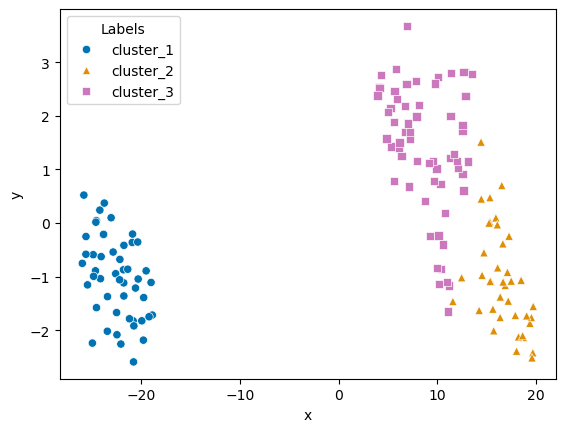

In [132]:
# put labels in order in the legend
order = ['cluster_1', 'cluster_2', 'cluster_3']
# choose color palette
colors = sns.color_palette("colorblind")
color_palette = [colors[0], colors[1], colors[4]]
# choose 3 different shapes as marker for each label
label_markers = ['o', '^', 's']

sns.scatterplot(x = "x", y = "y", data = train, hue = 'Labels', hue_order = order, palette = color_palette, style = 'Labels', style_order = order, markers = label_markers)

plt.show()

## Part 2

After running k-means 5 times to compare the validation accuracy, I saw that 4 out of 5 times the points were clustered correctly, matching up with what is in the validation labels. Here are those 4 points (I have given the Id column value for each point, but the dataframe index cane be found by subtracting each index by 1):

- (64, 136, 113)
- (90, 151, 23)
- (98, 106, 31)
- (66, 51, 62)

The 5th run, with points (136, 62, 18) was different:

| Labels | Predicted | 
| :---: | :---: |
| cluster_x | cluster_1 |
| cluster_x | cluster_3 |
| cluster_x | cluster_1 |
| cluster_y | cluster_1 |
| cluster_y | cluster_2 |
| cluster_y | cluster_2 |
| cluster_z | cluster_2 |
| cluster_z | cluster_2 |
| cluster_z | cluster_2 |

This is the only run of the validation set that I saw throughout my time working on this part that yielded predicted results that are different from the actual labels. Upon looking at the points, there are multiple values for the same features that are exactly the same (and this is the only set of centroids where this occurs). Since the points are pretty close to each other and share some of the same values, I think this negatively affected the validation accuracy. 

In [133]:
train.iloc[[135, 61, 17]]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Labels,x,y
135,136,4.8,3.0,1.4,0.3,cluster_1,-24.624752,0.014508
61,62,5.6,3.0,4.5,1.5,cluster_3,8.133477,2.203378
17,18,5.1,3.5,1.4,0.3,cluster_1,-21.797335,-1.117786
